# **Задание 1.  A/B–тестирование.**

1.1 Условие

Одной из основных задач аналитика в нашей команде является корректное проведение экспериментов. Для этого мы применяем метод A/B–тестирования. В ходе тестирования одной гипотезы целевой группе была предложена новая механика оплаты услуг на сайте, у контрольной группы оставалась базовая механика. В качестве задания вам необходимо проанализировать итоги эксперимента и сделать вывод, стоит ли запускать новую механику оплаты на всех пользователей.

1.2 Входные данные

В качестве входных данных вы имеете 4 csv-файла:

`groups.csv` – файл с информацией о принадлежности пользователя к контрольной или экспериментальной группе (А – контроль, B – целевая группа)

`groups_add.csv` – дополнительный файл с пользователями, который вам прислали спустя 2 дня после передачи данных

`active_studs.csv` – файл с информацией о пользователях, которые зашли на платформу в дни проведения эксперимента.

`checks.csv` – файл с информацией об оплатах пользователей в дни проведения эксперимента.

1.3 Вопросы

Предлагаем вам ответить на следующие вопросы:

На какие метрики вы смотрите в ходе анализа и почему?
Имеются ли различия в показателях и с чем они могут быть связаны?
Являются ли эти различия статистически значимыми?
Стоит ли запускать новую механику на всех пользователей?
Данный список вопросов не является обязательным, и вы можете при своём ответе опираться на собственный план.

1.4 Требования к ответу

При выполнении тестового задания необходимо использовать язык программирования Python.
В файле обязательно должны быть комментарии к тем действиям, которые вы выполняете с данными.
Файл должен представлять собой законченный отчёт с выводами, сделанными в ходе исследования.

## **Решение**

**ГИПОТЕЗА H₀:** Изменение механики оплаты услуг не влияет на поведение пользователей.

**Условие:**

Две группы:

```
A    : Контрольная   (14 693 человека)    - базовая механика оплаты услуг
B    : Тестовая      (59 883 человека)    - новая механика оплаты услуг
```

**Метрики и результат исследования**
```
Метрика                      Интерпритация                                  Результат

Основные:
- CR (conversion rate)     Конверсия в оплату из активных пользователей     Тест не способен уловить разницу

Прокси метрики:
- ARPU                     Средний доход на пользователя                    Тест не способен уловить разницу
- ARPPU                    Средний доход на платящего пользователя          ARPPU вырос на 28.8%, но устойчивость теста требует проверки на большей выборке A.
- was_active_rate          Доля активных пользователей                      Активность выросла на +8.5%, но устойчивость теста требует проверки на большей выборке A.
```

**КРАТКИЕ ВЫВОДЫ**

Тест требует доработки дизайна, но представленные данные указывают на перспективность дальнейшего исследования новой механики. Так, метрика ARPPU значимо увеличилась, т.е. платящие пользователи стали больше тратить (на 28%), а активность пользователей увеличилась на 8.5%, однако, это прокси метрики. Тест по основной метрике CR - конверсия в оплату из активных пользователей не состоялся, оказался не чувствительный, поэтому все тесты требуют проверки на большей выборке и сблаллансированных по размеру группах, сейчас группа А в 4 раза меньше В.

**Содержание набора данных:**

```
id, student_id  : идентификационный номер участника эксперимента
grp             : группа эксперимента A/B
was_active      : пользователи, которые зашли на платформу в день экперимента
rev             : наличие и сумма оплаты пользователя в день эксперимента
```

## **Загрузка и предобработка данных**

In [ ]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from urllib.parse import urlencode
from tqdm import tqdm
from statsmodels.stats.power import tt_ind_solve_power, zt_ind_solve_power, TTestIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import norm

In [ ]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

# функция для загрузочной ссылки
def download_url(public_key):
  final_url = base_url + urlencode(dict(public_key=public_key))
  response = requests.get(final_url)
  download_url = response.json()['href']
  return download_url

In [ ]:
public_key_cheks = 'https://disk.yandex.ru/d/pH1q-VqcxXjsVA'
public_key_activ_studs = 'https://disk.yandex.ru/d/Tbs44Bm6H_FwFQ'
public_key_group_add = 'https://disk.yandex.ru/d/5Kxrz02m3IBUwQ'
public_key_groups = 'https://disk.yandex.ru/d/UhyYx41rTt3clQ'

In [ ]:
cheks = pd.read_csv(download_url(public_key_cheks), sep=';')
activ_studs = pd.read_csv(download_url(public_key_activ_studs), sep=';')
group_add = pd.read_csv(download_url(public_key_group_add), sep=',')
groups = pd.read_csv(download_url(public_key_groups), sep=';')

In [ ]:
cheks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  541 non-null    int64  
 1   rev         541 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.6 KB


In [ ]:
activ_studs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  8341 non-null   int64
dtypes: int64(1)
memory usage: 65.3 KB


In [ ]:
group_add.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      92 non-null     int64 
 1   grp     92 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [ ]:
groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74484 entries, 0 to 74483
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74484 non-null  int64 
 1   grp     74484 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [ ]:
# Объединим две группы
groups = pd.concat([groups, group_add], ignore_index=True)

# Проверим, что нет повторов id
is_unique = groups['id'].nunique() == len(groups)
print("Все значения уникальны:", is_unique)

Все значения уникальны: True


In [ ]:
# Добавим к group какие студенты были активными
groups['was_active'] = groups['id'].isin(activ_studs['student_id'])

# Переименуем колонку student_id в id, чтобы можно было соединить
cheks = cheks.rename(columns={'student_id': 'id'})

# Объединяем по id: все из groups, rev добавится, если есть
df = pd.merge(groups, cheks, on='id', how='left')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74576 entries, 0 to 74575
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          74576 non-null  int64  
 1   grp         74576 non-null  object 
 2   was_active  74576 non-null  bool   
 3   rev         541 non-null    float64
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 1.8+ MB


In [ ]:
print('Размер выборки для группы А:', len(df.query('grp == "A"')))

Размер выборки для группы А: 14693


In [ ]:
print('Размер выборки для группы B:', len(df.query('grp == "B" ')))

Размер выборки для группы B: 59883


Размер группы B = 59 883, а группы A = 14 693.

Это очень неравномерное распределение участников.

Такая диспропорция между группами снижает доверие к итогам A/B-теста. Далее необходимо анализировать с учётом дисбаланса. В данной работе использую метод бутстрап.



**ВЫВОД**

В ходе анализа данные были проверены на дубликаты и пропуски, таковых не обнаружено. 4 исходные таблицы объеденены в один датасет.

Также, определены размеры выборок для A и для B. Группы распределены крайне неравномерно, тестовая группа В в 4 раза больше контрольной группы А. В дальнейшей работе необходимо учитывать данный дисбалланс.

Данные предобработаны и готовы к анализу

## **Анализ и проверка гипотез.**

Определим метрики для анализа:
```
Метрика                         Интерпритация

Основные:
- CR (conversion rate)          Конверсия в оплату из активных пользователей (rev > 0 & was_active == True)

Прокси метрики:
- ARPU                          Средний доход на пользователя (mean(rev))
- ARPPU                         Средний доход на платящего пользователя (mean(rev) среди rev > 0)
- was_active_rate               Доля активных пользователей
```

Почему такие метрики:

`CR` - Измеряет эффективность новой механики оплаты для «горячих» пользователей. Чувствительная к изменению технологии оплаты.

`ARPU` - Оценивает средний доход на всех пользователей

`ARPPU` - Показывает ценность платящих

`was_active_rate` - Контролирует баланс активности между группами

In [ ]:
# Подготовим флаги
df['rev'] = df['rev'].fillna(0)
df['paid'] = df['rev'] > 0

In [ ]:
summary = df.groupby('grp').agg(
    users=('id', 'count'),
    was_active_rate=('was_active', 'mean'),
    cr=('paid', lambda x: x[df.loc[x.index, 'was_active']].mean()),  # CR только для активных
    arpu=('rev', 'mean'),
    arppu=('rev', lambda x: x[x > 0].mean()),
    payers=('paid', 'sum')
).reset_index()

summary['grp'] = summary.index.map({0: 'A', 1: 'B'})

summary

,grp,users,was_active_rate,cr,arpu,arppu,payers
0,A,14693,0.104676,0.050715,6.268019,860.710280,107
1,B,59883,0.113605,0.046156,8.036171,1108.824893,434


Доля активных пользователей ('was_activ') схожие, поэтому в данной работе можем опустить использование стратификации по активности.

### **CR (conversion rate)** -  Конверсия в оплату из активных пользователей (rev > 0)

H₀: CR в группах равны

H1: CR в группах различаются

In [ ]:
summary['cr']

,cr
0,0.050715
1,0.046156


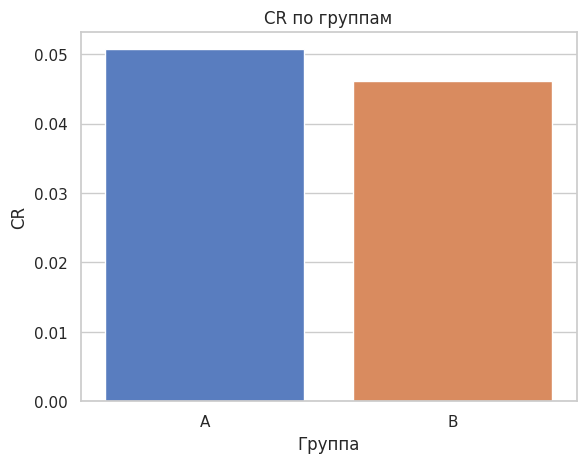

In [ ]:
sns.barplot(data=summary.reset_index(), x='grp', y='cr', palette='muted', hue='grp')
plt.title('CR по группам')
plt.xlabel('Группа')
plt.ylabel('CR')
plt.show()

In [ ]:
rel_change = ((summary['cr'][1]- summary['cr'][0])/summary['cr'][0])*100
print('Показатели метрики отличаются на', rel_change.round(2), '%')

Показатели метрики отличаются на -8.99 %


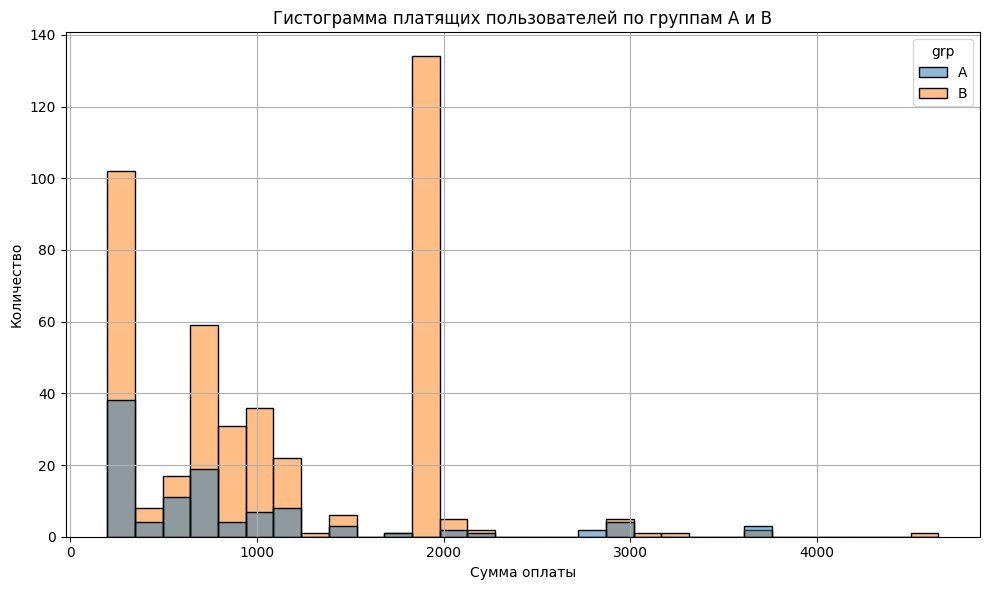

In [ ]:
paid_users = df[df['paid'] == True]

plt.figure(figsize=(10, 6))
sns.histplot(data=paid_users, x='rev', hue='grp', bins=30)

plt.title('Гистограмма платящих пользователей по группам A и B')
plt.xlabel('Сумма оплаты')
plt.ylabel('Количество')
plt.grid(True)
plt.tight_layout()
plt.show()

Распределение не является нормальным.

В связи с тем, что распределение ненормальное и две группы сильно различаются по размеру, для теста использую метод бутстрап, который поможет нивелировать разницу выборок:

- Случайно берём выборку из группы A (с возвращением).

- Случайно берём выборку из группы B.

- Считаем разницу метрики (например, mean(B) - mean(A)).

- Повторяем тысячи раз.

- Смотрим на распределение этих разниц → строим доверительный интервал.

- Если интервал не включает 0, то разница значима.

- **Бутстрап**

In [ ]:
# Бутстрап функция
def bootstrap_metric(df, group_col, group_name, metric_func, n_bootstrap):
    group_data = df[df[group_col] == group_name]
    metric_values = []

    for _ in tqdm(range(n_bootstrap)):
        sample = group_data.sample(frac=1, replace=True)  # Ресемплирование с повторением
        metric = metric_func(sample)
        metric_values.append(metric)

    return np.array(metric_values)

In [ ]:
# Функция для расчета метрик
def calculate_cr(data):
    return data.query('was_active == True')['paid'].mean()

# Запуск бутстрапа для групп A и B
n_bootstrap = 10000

boot_a = bootstrap_metric(df, 'grp', 'A', calculate_cr, n_bootstrap)
boot_b = bootstrap_metric(df, 'grp', 'B', calculate_cr, n_bootstrap)

results = {
    'CR_A': boot_a,
    'CR_B': boot_b,
    'CR_diff': boot_b - boot_a
}

100%|██████████| 10000/10000 [00:59<00:00, 167.56it/s]


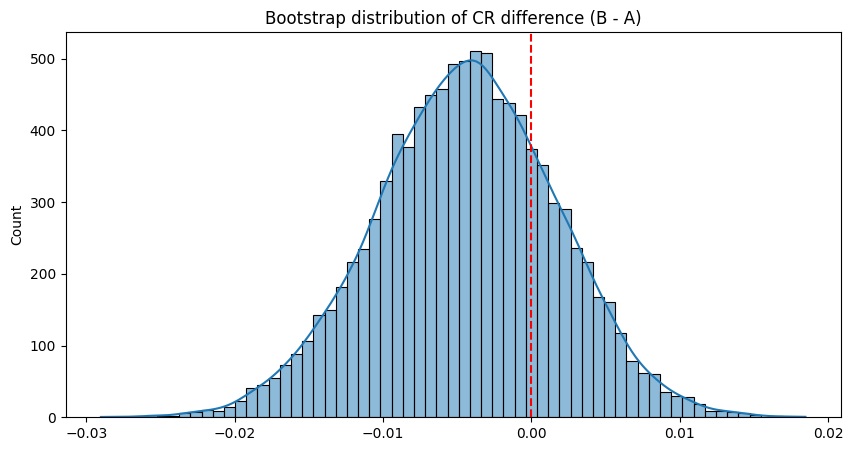

CR: p-value = 0.7624
CR: 95% CI = [-0.0166, 0.0074]


In [ ]:
# Визуализация
plt.figure(figsize=(10, 5))
sns.histplot(results['CR_diff'], kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Bootstrap distribution of CR difference (B - A)')
plt.show()

# Расчет статистик
p_value = (results['CR_diff'] <= 0).mean()
print(f"CR: p-value = {p_value:.4f}")

ci_lower = np.percentile(results['CR_diff'], 2.5)
ci_upper = np.percentile(results['CR_diff'], 97.5)
print(f"CR: 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

**Статистическая значимость:**

p-value > 0.05 (стандартного уровня значимости), значит, разница между группами не статистически значима.

Нет оснований отвергать нулевую гипотезу о равенстве конверсий в группах A и B.

**Размер эффекта:**

Доверительный интервал включает ноль (0 находится между -0.00165 и 0.0072), что подтверждает отсутствие значимого эффекта.

- **В дополнение проверим мощность теста:**

In [ ]:
n_A = len(df[(df['grp'] == 'A') & (df['was_active'] == True)])
n_B = len(df[(df['grp'] == 'B') & (df['was_active'] == True)])
cr_A = df[(df['grp'] == 'A') & (df['was_active'] == True)]['paid'].mean()
cr_B = df[(df['grp'] == 'B') & (df['was_active'] == True)]['paid'].mean()

# Размер эффекта (Cohen's h)
effect_size = proportion_effectsize(cr_A, cr_B)

# Мощность теста (для alpha=0.05)
power = zt_ind_solve_power(
    effect_size=effect_size,
    nobs1=n_A,
    alpha=0.05,
    ratio=n_B / n_A
)

print(f"Размер групп: A={n_A}, B={n_B}")
print(f"Конверсии: A={cr_A:.4f}, B={cr_B:.4f}")
print(f"Размер эффекта: {effect_size:.4f}")
print(f"Мощность теста: {power:.2%}")

Размер групп: A=1538, B=6803
Конверсии: A=0.0507, B=0.0462
Размер эффекта: 0.0212
Мощность теста: 11.69%


- **Минимальный эффект**

In [ ]:
mde = zt_ind_solve_power(
    effect_size=None,
    nobs1=n_A,
    alpha=0.05,
    power=0.8,
    ratio=n_B / n_A
)

print(f"Минимальный детектируемый эффект (MDE): {mde:.4}")

Минимальный детектируемый эффект (MDE): 0.0791


| Параметр	| Группа A 	|Группа B	|Разница (A - B)|
|-----------|-----------|---------|---------------|
|Размер группы	| 1,538	|6,803	|-
|Конверсия (CR)	|0.0507	|0.0462	|-0.0045
|Размер эффекта (Cohen's h)	|-	|-	|0.0212
|Мощность теста	|-	|-	|11.69%
|MDE	|-	|-	|0.79

Тест имеет низкую мощность (11.69%), что объясняет, почему мы не обнаружили значимой разницы (p-value = 0.76).

Причины:

Несбалансированные группы: Группа A — 14.7к пользователей, группа B — 59.9к. Соотношение 1:4 снижает мощность (оптимально 1:1).

Маленькая конверсия: Если CR близок к 0.05, нужно больше данных для детектирования эффекта.

Слишком маленький эффект: при MDE = 7.91% — тест не способен уловить разницу.


**Вывод:** Тест несостоятельный.

Результаты теста говорят о том, что новая механика оплаты (группа B) не лучше и не хуже текущей (группа A) (p-value > 0.05).

Однако! Мощность 11.69% крайне низка (целевой минимум — 80%) - результаты ненадёжны. Это говорит о том, что тест нерабочий и его результаты незначимы из-за низкой мощности.

Фактическая разница конверсий (0.0045) существенно меньше MDE (0.79) - тест не мог обнаружить такой маленький эффект.

Таким образом, результаты теста не могут быть приняты во внимание.

В связи с этим ниже рассмотрим другие метрики.

### **ARPU** -  Средний доход на пользователя (mean(rev))

H₀: ARPU в группах равны

H1: ARPU в группах различаются

In [ ]:
summary['arpu']

,arpu
0,6.268019
1,8.036171


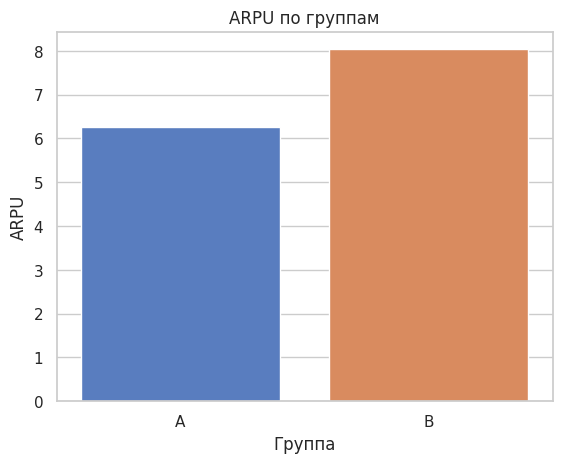

In [ ]:
sns.barplot(data=summary.reset_index(), x='grp', y='arpu', palette='muted', hue='grp')
plt.title('ARPU по группам')
plt.xlabel('Группа')
plt.ylabel('ARPU')
plt.show()

In [ ]:
rel_change = ((summary['arpu'][1]- summary['arpu'][0])/summary['arpu'][0])*100
print('Показатели метрики отличаются на', rel_change.round(2), '%')

Показатели метрики отличаются на 28.21 %


- **Бутстрап**

In [ ]:
# Функция для расчета метрик
def calculate_arpu(data):
    return data['rev'].mean()

# Запуск бутстрапа для групп A и B
n_bootstrap = 10000

boot_a = bootstrap_metric(df, 'grp', 'A', calculate_arpu, n_bootstrap)
boot_b = bootstrap_metric(df, 'grp', 'B', calculate_arpu, n_bootstrap)

results = {
    'arpu_A': boot_a,
    'arpu_B': boot_b,
    'arpu_diff': boot_b - boot_a
}

100%|██████████| 10000/10000 [00:32<00:00, 306.47it/s]


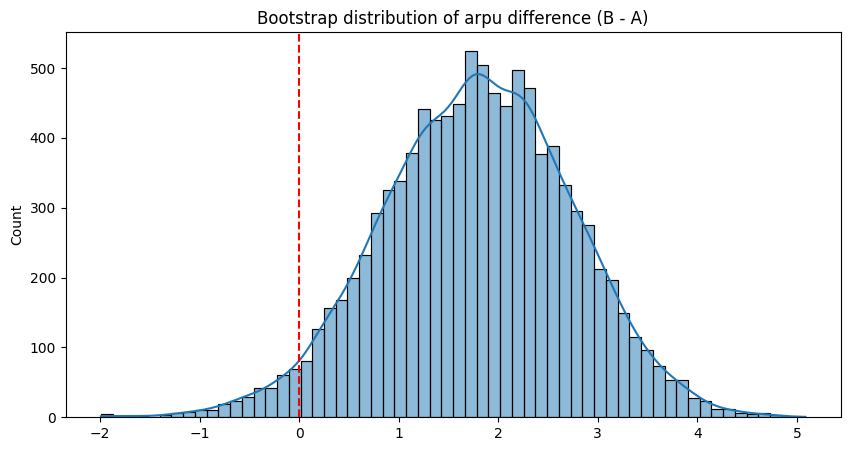

arpu: p-value = 0.0324
arpu: 95% CI = [-0.1242, 3.5819]


In [ ]:
# Визуализация
plt.figure(figsize=(10, 5))
sns.histplot(results['arpu_diff'], kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Bootstrap distribution of arpu difference (B - A)')
plt.show()

# Расчет статистик
p_value = (results['arpu_diff'] <= 0).mean()
print(f"arpu: p-value = {p_value:.4f}")

ci_lower = np.percentile(results['arpu_diff'], 2.5)
ci_upper = np.percentile(results['arpu_diff'], 97.5)
print(f"arpu: 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

**Статистическая значимость:**

p-value < 0.05 (стандартного уровня значимости), значит, разница между группами статистически значима.

Есть основания отвергать нулевую гипотезу о равенстве среднего дохода в группах A и B.

**Размер эффекта:**

Однако, доверительный интервал включает ноль (0 находится между -0.00165 и 0.0072), что подтверждает отсутствие значимого эффекта.

- **В дополнение проверим мощность теста:**

In [ ]:
# Данные для групп A и B (только активные пользователи)
group_A = df[(df['grp'] == 'A')]
group_B = df[(df['grp'] == 'B')]

# Средняя выручка (ARPU)
arpu_A = group_A['rev'].mean()
arpu_B = group_B['rev'].mean()

# Стандартное отклонение (объединённое)
std_pooled = ((group_A['rev'].std()**2 + group_B['rev'].std()**2) / 2)**0.5

# Размер эффекта Cohen's d
effect_size = (arpu_B - arpu_A) / std_pooled

# Мощность теста (t-тест для независимых выборок)
power = TTestIndPower().solve_power(
    effect_size=effect_size,
    nobs1=len(group_A),
    alpha=0.05,
    ratio=len(group_B)/len(group_A)
)

print(f"Размер групп: A={len(group_A)}, B={len(group_B)}")
print(f"ARPU: A={arpu_A:.2f}, B={arpu_B:.2f}")
print(f"Размер эффекта (Cohen's d): {effect_size:.4f}")
print(f"Мощность теста: {power:.2%}")

Размер групп: A=14693, B=59883
ARPU: A=6.27, B=8.04
Размер эффекта (Cohen's d): 0.0165
Мощность теста: 43.32%


- **Минимальный эффект**

In [ ]:
# Параметры
alpha = 0.05  # Уровень значимости
power = 0.8   # Желаемая мощность
n_A = len(group_A)
n_B = len(group_B)
ratio = n_B / n_A

# Объединённое стандартное отклонение
std_A = group_A['rev'].std()
std_B = group_B['rev'].std()
std_pooled = np.sqrt((std_A**2 + std_B**2) / 2)

# Вычисляем MDE (Cohen's d)
power_analysis = TTestIndPower()
mde_d = power_analysis.solve_power(
    effect_size=None,
    nobs1=n_A,
    alpha=alpha,
    power=power,
    ratio=ratio
)

# Преобразуем в абсолютную разницу
mde_absolute = float(mde_d) * std_pooled  # Явное преобразование в float

print(f"Размер групп: A={n_A}, B={n_B}")
print(f"Объединённое std: {std_pooled:.2f}")
print(f"MDE (Cohen's d): {float(mde_d):.4f}")
print(f"MDE для ARPU: {mde_absolute:.2f} денежных единиц");

Размер групп: A=14693, B=59883
Объединённое std: 107.20
MDE (Cohen's d): 0.0258
MDE для ARPU: 2.77 денежных единиц


| Параметр	| Группа A 	|Группа B	|Разница (A - B)|
|-----------|-----------|---------|---------------|
|Размер группы	| 1,538	|6,803	|-
|ARPU	|6.27	|8.04	|+1.67
|Размер эффекта (Cohen's h)	|-	|-	|0.0258
|Мощность теста	|-	|-	|43.32%
|MDE	|-	|-	|2.77

Фактическая разница ARPU (B - A) 1.67 — это меньше MDE.
Тест не мог обнаружить такую небольшую разницу.

Тест имеет низкую мощность (43%). Тест недостаточно чувствителен, чтобы обнаружить существующую разницу.

Причины:

- Несбалансированные группы: Группа A — 14.7к пользователей, группа B — 59.9к.
Соотношение 1:4 снижает мощность (оптимально 1:1).

- Маленький размер выборки.

In [ ]:
required_n = TTestIndPower().solve_power(
    effect_size=0.0258,
    alpha=0.05,
    power=0.8,
    ratio=1
)
print(f"Требуется пользователей на группу: {int(required_n)}")

Требуется пользователей на группу: 23583


Даже если бы группы были равны, для обнаружения эффекта 10.71 при std=302.35 нужно ~12,5 тыс. пользователей на группу.


**Вывод:** тест несостоятельный.

Результаты теста говорят о том, что новая механика оплаты (группа B) приносит больший доход на пользователя, чем текущая (группа A) (p-value < 0.05).

Однако! Мощность 24% крайне низка (целевой минимум — 80%) - результаты ненадёжны. Это говорит о том, что тест нерабочий и его результаты незначимы из-за низкой мощности.

Фактическая разница ARPU (10.7) существенно меньше MDE (23.9) - тест не мог обнаружить такой маленький эффект.

Это может быть связано с большой разницей в размере выборок и маленьким размером выборки (min 12,5 тыс).

Таким образом, результаты теста не могут быть приняты во внимание

### **ARPPU** - Средний доход на платящего пользователя

H₀: ARPPU в группах равны

H1: ARPPU в группах различаются

In [ ]:
summary['arppu']

,arppu
0,860.710280
1,1108.824893


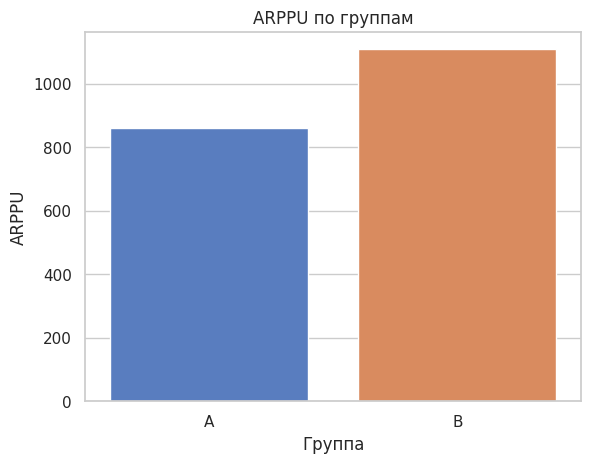

In [ ]:
sns.barplot(data=summary.reset_index(), x='grp', y='arppu', palette='muted', hue='grp')
plt.title('ARPPU по группам')
plt.xlabel('Группа')
plt.ylabel('ARPPU')
plt.show()

In [ ]:
rel_change = ((summary['arppu'][1]- summary['arppu'][0])/summary['arppu'][0])*100
print('Показатели метрик отличаются на', rel_change.round(2), '%')

Показатели метрик отличаются на 28.83 %


- **Бутстрап**

In [ ]:
# Функция для расчета метрик
def calculate_arppu(data):
    return data[data['paid']]['rev'].mean()

# Запуск бутстрапа для групп A и B
n_bootstrap = 10000

boot_a = bootstrap_metric(df, 'grp', 'A', calculate_arppu, n_bootstrap)
boot_b = bootstrap_metric(df, 'grp', 'B', calculate_arppu, n_bootstrap)

results = {
    'arppu_A': boot_a,
    'arppu_B': boot_b,
    'arppu_diff': boot_b - boot_a
}

100%|██████████| 10000/10000 [00:36<00:00, 274.96it/s]


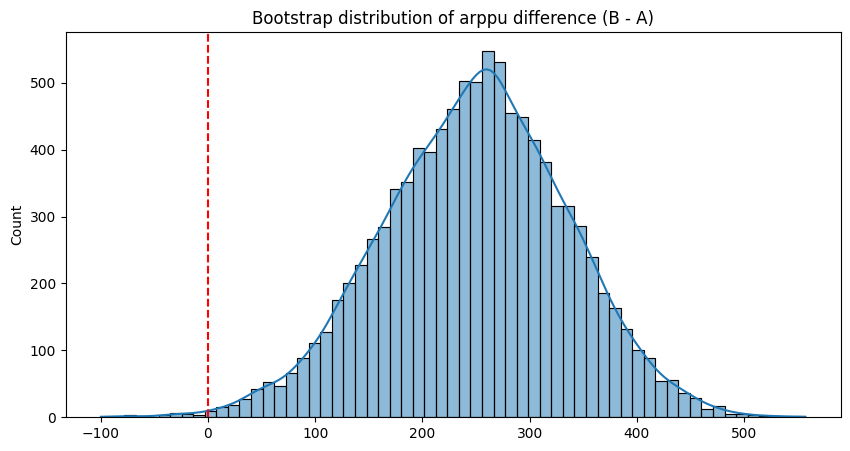

arppu: p-value = 0.0027
arppu: 95% CI = [73.4336, 413.2212]


In [ ]:
# Визуализация
plt.figure(figsize=(10, 5))
sns.histplot(results['arppu_diff'], kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Bootstrap distribution of arppu difference (B - A)')
plt.show()

# Расчет статистик
p_value = (results['arppu_diff'] <= 0).mean()
print(f"arppu: p-value = {p_value:.4f}")

ci_lower = np.percentile(results['arppu_diff'], 2.5)
ci_upper = np.percentile(results['arppu_diff'], 97.5)
print(f"arppu: 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

**Статистическая значимость:**

p-value < 0.05 (стандартного уровня значимости), значит, разница между группами статистически значима.

Есть основания отвергать нулевую гипотезу о равенстве среднего дохода в группах A и B.

**Размер эффекта:**

Однако, доверительный интервал не включает ноль, что подтверждает наличие значимого эффекта.

- **В дополнение проверим мощность теста:**

In [ ]:
# Данные для групп A и B
group_A = df[(df['grp'] == 'A') & (df['paid'])]
group_B = df[(df['grp'] == 'B') & (df['paid'])]

# Средняя выручка
arpu_A = group_A['rev'].mean()
arpu_B = group_B['rev'].mean()

# Стандартное отклонение (объединённое)
std_pooled = ((group_A['rev'].std()**2 + group_B['rev'].std()**2) / 2)**0.5

# Размер эффекта Cohen's d
effect_size = (arpu_B - arpu_A) / std_pooled

# Мощность теста (t-тест для независимых выборок)
power = TTestIndPower().solve_power(
    effect_size=effect_size,
    nobs1=len(group_A),
    alpha=0.05,
    ratio=len(group_B)/len(group_A)
)

print(f"Размер групп: A={len(group_A)}, B={len(group_B)}")
print(f"ARPPU: A={arpu_A:.2f}, B={arpu_B:.2f}")
print(f"Размер эффекта (Cohen's d): {effect_size:.4f}")
print(f"Мощность теста: {power:.2%}")

Размер групп: A=107, B=434
ARPPU: A=860.71, B=1108.82
Размер эффекта (Cohen's d): 0.3182
Мощность теста: 83.72%


- **Минимальный эффект**

In [ ]:
# Параметры
alpha = 0.05  # Уровень значимости
power = 0.8   # Желаемая мощность
n_A = len(group_A)
n_B = len(group_B)
ratio = n_B / n_A

# Объединённое стандартное отклонение
std_A = group_A['rev'].std()
std_B = group_B['rev'].std()
std_pooled = np.sqrt((std_A**2 + std_B**2) / 2)

# Вычисляем MDE (Cohen's d)
power_analysis = TTestIndPower()
mde_d = power_analysis.solve_power(
    effect_size=None,
    nobs1=n_A,
    alpha=alpha,
    power=power,
    ratio=ratio
)

# Преобразуем в абсолютную разницу
mde_absolute = float(mde_d) * std_pooled  # Явное преобразование в float

print(f"Размер групп: A={n_A}, B={n_B}")
print(f"Объединённое std: {std_pooled:.2f}")
print(f"MDE (Cohen's d): {float(mde_d):.4f}")
print(f"MDE для ARPPU: {mde_absolute:.2f} денежных единиц");

Размер групп: A=107, B=434
Объединённое std: 779.74
MDE (Cohen's d): 0.3029
MDE для ARPPU: 236.21 денежных единиц


<ipython-input-36-d2a5a59ac87b>:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mde_absolute = float(mde_d) * std_pooled  # Явное преобразование в float
<ipython-input-36-d2a5a59ac87b>:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"MDE (Cohen's d): {float(mde_d):.4f}")


| Параметр	| Группа A 	|Группа B	|Разница (A - B)|
|-----------|-----------|---------|---------------|
|Размер группы	| 107	|434	|-
|ARPPU	|860.71	|1108.82	|+248.11
|Размер эффекта (Cohen's h)	|-	|-	|0.0329
|Мощность теста	|-	|-	|83.72%
|MDE	|-	|-	|236.21

Фактическая разница ARPU (B - A) = 1108.82 - 860.71 = 248.11 — это больше MDE.

Тест имеет низкую мощность (84%). Тест достаточно чувствителен, чтобы обнаружить существующую разницу.

In [ ]:
required_n = TTestIndPower().solve_power(
    effect_size=0.329,
    alpha=0.05,
    power=0.8,
    ratio=1
)
print(f"Требуется пользователей на группу: {int(required_n)}")

Требуется пользователей на группу: 145


Необходимо увеличить размер контрольной выборки до 145 на группу


**Вывод:** Новая механика оплаты (группа B) увеличила ARPPU на 248.11 (на 28.8% относительно группы A), и этот эффект значим (p < 0.05).

Однако, группа A недостаточного размера, меньше минимально требуемой 145 (A=107, B=434).

Даже если эффект есть, его устойчивость требует проверки на большей выборке.

Мощность >80% — тест адекватно обнаружил эффект.

MDE (236.21) близок к фактической разнице (248.11) — расчёт был точен.

Необходимо увеличить размер выборки до 145 на группу.

### **was_active_rate** - Доля активных пользователей

H₀: was_active_rate в группах равны

H1: was_active_rate в группах различаются

In [ ]:
summary['was_active_rate']

,was_active_rate
0,0.104676
1,0.113605


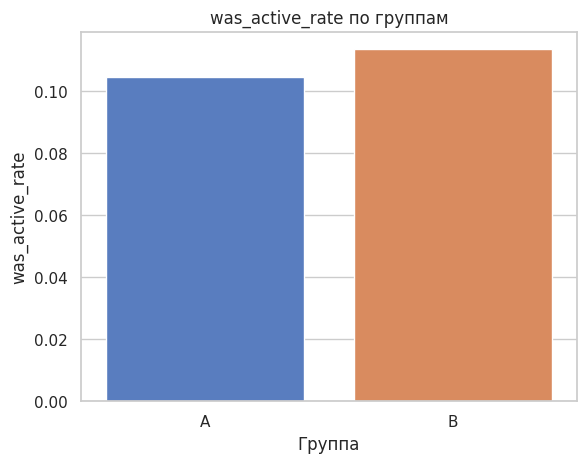

In [ ]:
sns.barplot(data=summary.reset_index(), x='grp', y='was_active_rate', palette='muted', hue='grp')
plt.title('was_active_rate по группам')
plt.xlabel('Группа')
plt.ylabel('was_active_rate')
plt.show()

In [ ]:
rel_change = ((summary['was_active_rate'][1]- summary['was_active_rate'][0])/summary['was_active_rate'][0])*100
print('Показатели метрик отличаются на', rel_change.round(2), '%')

Показатели метрик отличаются на 8.53 %


- **Бутстрап**

In [ ]:
# Функция для расчета метрик
def calculate_active_share(data):
    return data['was_active'].mean()

# Запуск бутстрапа для групп A и B
n_bootstrap = 10000

boot_a = bootstrap_metric(df, 'grp', 'A', calculate_active_share, n_bootstrap)
boot_b = bootstrap_metric(df, 'grp', 'B', calculate_active_share, n_bootstrap)

results = {
    'was_active_rate_A': boot_a,
    'was_active_rate_B': boot_b,
    'was_active_rate_diff': boot_b - boot_a
}

100%|██████████| 10000/10000 [00:37<00:00, 265.50it/s]


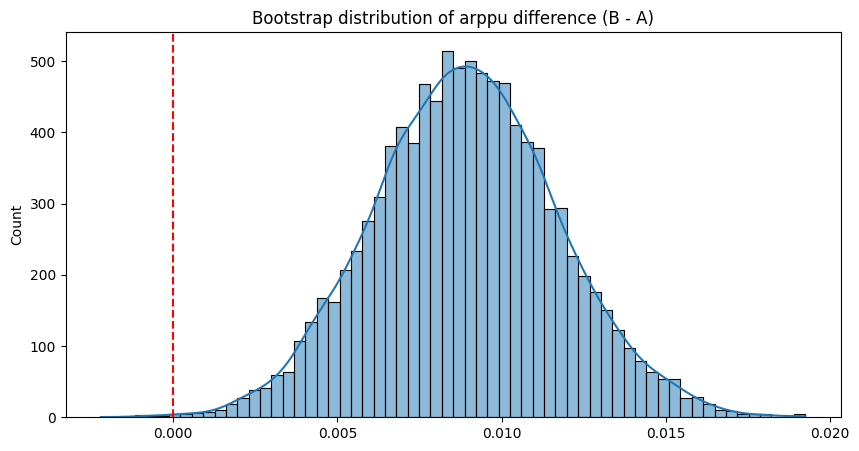

was_active_rate: p-value = 0.0009
was_active_rate: 95% CI = [0.0034, 0.0146]


In [ ]:
# Визуализация
plt.figure(figsize=(10, 5))
sns.histplot(results['was_active_rate_diff'], kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Bootstrap distribution of arppu difference (B - A)')
plt.show()

# Расчет статистик
p_value = (results['was_active_rate_diff'] <= 0).mean()
print(f"was_active_rate: p-value = {p_value:.4f}")

ci_lower = np.percentile(results['was_active_rate_diff'], 2.5)
ci_upper = np.percentile(results['was_active_rate_diff'], 97.5)
print(f"was_active_rate: 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

**Статистическая значимость:**

p-value < 0.05 (стандартного уровня значимости), значит, разница между группами статистически значима.

Есть основания отвергать нулевую гипотезу о равенстве среднего дохода в группах A и B.

**Размер эффекта:**

Доверительный интервал включает ноль (0 находится между 0.0033 и 0.0145).

- **В дополнение проверим мощность теста:**

In [ ]:
# Фильтрация данных
group_A = df[df['grp'] == 'A']
group_B = df[df['grp'] == 'B']

# Расчет базовых показателей
n_A = len(group_A)
n_B = len(group_B)
p_A = group_A['was_active'].mean()
p_B = group_B['was_active'].mean()

# 1. Расчет текущего размера эффекта (Cohen's h)
current_effect_size = proportion_effectsize(p_A, p_B)

# 2. Расчет мощности текущего теста
current_power = zt_ind_solve_power(
    effect_size=current_effect_size,
    nobs1=n_A,
    alpha=0.05,
    ratio=n_B/n_A
)

# 3. Расчет MDE (минимального детектируемого эффекта)
mde_h = zt_ind_solve_power(
    effect_size=None,
    nobs1=n_A,
    alpha=0.05,
    power=0.8,
    ratio=n_B/n_A
)

# Преобразование Cohen's h в абсолютную разницу процентов
def h_to_absolute_diff(p, h):
    """Конвертирует Cohen's h в абсолютную разницу пропорций"""
    return np.sin(np.arcsin(np.sqrt(p)) + h/2)**2 - p

mde_absolute = h_to_absolute_diff(p_A, mde_h)

# Вывод результатов
print(f"Размер групп: A={n_A}, B={n_B}")
print(f"Доля активных: A={p_A:.4}, B={p_B:.4}")
print(f"Текущий размер эффекта (Cohen's h): {current_effect_size:.4f}")
print(f"Текущая мощность теста: {current_power:.2%}")
print(f"MDE (Cohen's h): {mde_h:.4f}")
print(f"MDE (абсолютная разница): {abs(mde_absolute):.3}")
print(f"Требуемый размер группы A для мощности 80%: {int(zt_ind_solve_power(effect_size=current_effect_size, nobs1=None, alpha=0.05, power=0.8, ratio=1))}")

Размер групп: A=14693, B=59883
Доля активных: A=0.1047, B=0.1136
Текущий размер эффекта (Cohen's h): -0.0286
Текущая мощность теста: 87.52%
MDE (Cohen's h): 0.0258
MDE (абсолютная разница): 0.00803
Требуемый размер группы A для мощности 80%: 19135


| Параметр	| Группа A 	|Группа B	|Разница (A - B)|
|-----------|-----------|---------|---------------|
|Размер группы	| 14 693	|59 883	|-
|was_active_rate	|0.1047	|0.1136	|+0.0089
|Размер эффекта (Cohen's h)	|-	|-	|-0.0258
|Мощность теста	|-	|-	|87.52%
|MDE	|-	|-	|0.0080

Размер группы А (14693) меньше минимально допустимой (19135).


**Вывод:** Отвергаем нулевую гипотезу.

Группа B имеет более высокую долю активных пользователей (0.1136% vs 0.1047), разница +0.0089.

Высокая мощность (87.52%) означает, что тест достаточно чувствителен для обнаружения эффектов.

Текущая разница (0.0089) превышает MDE (0.0080), что говорит о статистической значимости.

Однако, для полностью корректного эксперимента требуется увеличение общей выборки.

# **Вывод**

Тест требует доработки дизайна, но представленные данные указывают на перспективность дальнейшего исследования новой механики. Так, метрика ARPPU значимо увеличилась, т.е. платящие пользователи стали больше тратить (на 28%), а активность пользователей увеличилась на 8.5%, однако все тесты требуют проверки на большей выборке и сблаллансированных группах.

Прочие проводимые тесты по выбранным метрикам (CR и ARPU) не способны уловить обнаруживаемую разницу, имеют маленькую мощность, MDE меньше требуемого или размер группы недостаочный.

Это может быть связано с тем, что группы А и В сильно несбаллансированы, а также размеры выборок недостаточны.

В эксперименте участвуют две сильно несбаллансированные группы, тестовая группа (В) почти в 4 раза больше контрольной (А).

Для нивелирования разницы в анализе был использован бутстрап, но этого оказалось недостаточно. Тесты показывают нечувствительность, необходимо выбрать равные размеры групп и увеличить размер группы А.

#**Задание 2. SQL**

##2.1 Очень усердные ученики.

2.1.1 Условие

Образовательные курсы состоят из различных уроков, каждый из которых состоит из нескольких маленьких заданий. Каждое такое маленькое задание называется "горошиной".

Назовём очень усердным учеником того пользователя, который хотя бы раз за текущий месяц правильно решил 20 горошин.

2.1.2 Задача

Дана таблица peas:

|Название атрибута	|Тип атрибута	|Смысловое значение|
|-------------------|-------------|------------------|
|st_id	|int	|ID ученика|
|timest	|timestamp	|Время решения карточки|
|correct	|bool	|Правильно ли решена горошина?
|subject	|text	|Дисциплина, в которой находится горошина


Необходимо написать оптимальный запрос, который даст информацию о количестве очень усердных студентов.NB! Под усердным студентом мы понимаем студента, который правильно решил 20 задач за текущий месяц.

2.1.3 Решение

```sql
with st_month_correct as (select
  st_id,
  count(*) as count,
  date_trunc('month', timest) as month
from
  peas
where
  correct = true
group by
  st_id,
  date_trunc('month', timest))
  
select count(distinct st_id)
from st_month_correct
where count >= 20;
```

##**2.2 Оптимизация воронки**

2.2.1 Условие

Образовательная платформа предлагает пройти студентам курсы по модели trial: студент может решить бесплатно лишь 30 горошин в день. Для неограниченного количества заданий в определенной дисциплине студенту необходимо приобрести полный доступ. Команда провела эксперимент, где был протестирован новый экран оплаты.

2.2.2 Задача

Дана таблицы: peas (см. выше), studs:

|Название атрибута	|Тип атрибута	|Смысловое значение|
|-------------------|-------------|------------------|
|st_id	|int	 |ID ученика|
|test_grp	|text	 |Метка ученика в данном эксперименте|

и final_project_check:

|Название атрибута	|Тип атрибута	|Смысловое значение|
|-------------------|-------------|------------------|
|st_id	|int 	|ID ученика
|sale_time	|timestamp	|Время покупки
|money	|int	|Цена, по которой приобрели данный курс
|subject	|text 	|Дисциплина

Необходимо в одном запросе выгрузить следующую информацию о группах пользователей:

- ARPU

- ARPAU

- CR в покупку

- СR активного пользователя в покупку

- CR пользователя из активности по математике (subject = ’math’) в покупку курса по математике

ARPU считается относительно всех пользователей, попавших в группы.

Активным считается пользователь, за все время решивший больше 10 задач правильно в любых дисциплинах.

Активным по математике считается пользователь, за все время решивший 2 или больше задач правильно по математике.

2.2.3 Решение

# **Задание 3. Python**

## 3.1.Реализуйте функцию, которая будет автоматически подгружать информацию из дополнительного файла `groups_add.csv` (заголовки могут отличаться) и на основании дополнительных параметров пересчитывать метрики.

**Решение**:

In [ ]:
def recalculate_metrics_from_url(csv_url):

    # Загружаем дополнительные группы по ссылке
    groups_add = pd.read_csv(csv_url, sep=',')

    # Объединим две группы
    groups_new = pd.concat([groups, group_add], ignore_index=True)
    # Добавим к group какие студенты были активными
    groups_new['was_active'] = groups_new['id'].isin(activ_studs['student_id'])

    # Переименуем колонку student_id в id, чтобы можно было соединить
    cheks_new = cheks.rename(columns={'student_id': 'id'})

    # Объединяем по id: все из groups, rev добавится, если есть
    df_new = pd.merge(groups_new, cheks_new, on='id', how='left')

    # Подготовим флаги
    df_new['rev'] = df_new['rev'].fillna(0)
    df_new['paid'] = df_new['rev'] > 0

    # Группируем и считаем метрики
    results = df.groupby('grp').apply(lambda x: pd.Series({
        'users': len(x),
        'cr': calculate_cr(x),
        'arpu': calculate_arpu(x),
        'arppu': calculate_arppu(x),
        'was_active_rate': calculate_active_share(x)
    })).reset_index()

    return results, df_new

**Проверка:**

Подготовка расчетов без `groups_add`

In [ ]:
cheks = pd.read_csv(download_url(public_key_cheks), sep=';')
activ_studs = pd.read_csv(download_url(public_key_activ_studs), sep=';')
groups = pd.read_csv(download_url(public_key_groups), sep=';')

In [ ]:
groups['was_active'] = groups['id'].isin(activ_studs['student_id'])
cheks = cheks.rename(columns={'student_id': 'id'})
data = pd.merge(groups, cheks, on='id', how='left')

In [ ]:
data['rev'] = data['rev'].fillna(0)
data['paid'] = data['rev'] > 0

Старые метрики:

In [ ]:
summary = data.groupby('grp').agg(
    users=('id', 'count'),
    cr=('paid', lambda x: x[data.loc[x.index, 'was_active']].mean()),  # CR только для активных
    arpu=('rev', 'mean'),
    arppu=('rev', lambda x: x[x > 0].mean()),
    was_active_rate=('was_active', 'mean')
).reset_index()

summary

,grp,users,cr,arpu,arppu,was_active_rate
0,A,14671,0.050814,6.277418,860.710280,0.104628
1,B,59813,0.046077,8.013810,1106.997699,0.113571


Новые метрики:

In [ ]:
new_metrics, df = recalculate_metrics_from_url(download_url(public_key_group_add))
new_metrics

<ipython-input-43-e47d8b17eae3>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df.groupby('grp').apply(lambda x: pd.Series({


,grp,users,cr,arpu,arppu,was_active_rate
0,A,14693.0,0.050715,6.268019,860.710280,0.104676
1,B,59883.0,0.046156,8.036171,1108.824893,0.113605


## 3.2.Реализуйте функцию, которая будет строить графики по получаемым метрикам.

**Решение:**

In [ ]:
def plot_metrics(metrics_df):

    # Устанавливаем стиль графиков
    sns.set(style="whitegrid")

    # Список метрик
    metric_cols = ['users', 'cr', 'arpu', 'arppu', 'was_active_rate']

    # Создаём фигуру с подграфиками
    fig, axes = plt.subplots(nrows=len(metric_cols), ncols=1, figsize=(6, 4 * len(metric_cols)))

    # Строим графики
    for i, metric in enumerate(metric_cols):
        ax = axes[i]
        sns.barplot(x='grp', y=metric, data=metrics_df, ax=ax, palette='muted', hue='grp')
        ax.set_title(f'{metric.upper()} по группам', fontsize=14)
        ax.set_xlabel('Группа')
        ax.set_ylabel(metric.upper())

        # Добавим подписи на столбики
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

**Проверка:**

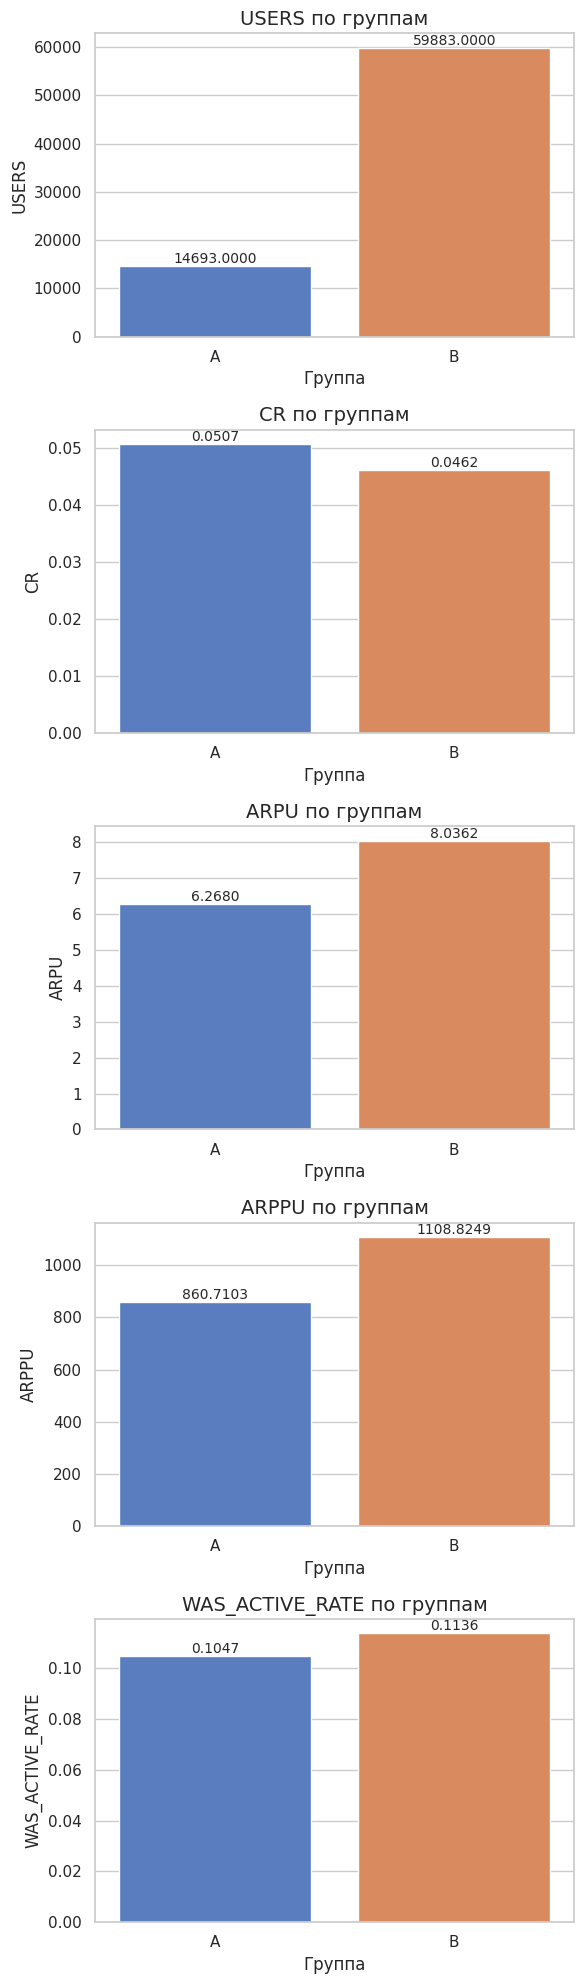

In [ ]:
# Строим графики
plot_metrics(new_metrics)